# 🚀 Fine-tuning IndoBERT: Binary Classification (Positif vs Negatif)

Notebook ini melatih model IndoBERT untuk klasifikasi sentimen biner setelah menghapus kelas 'Netral' yang terlalu sedikit datanya.
1. **Load Binary Data**: Menggunakan data yang sudah difilter dan diseimbangkan.
2. **Fine-tuning**: Melatih `BertForSequenceClassification` dengan 2 label.
3. **Evaluasi**: Menguji performa pada data uji biner.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import torch
import os
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Config
BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
TRAIN_PATH = os.path.join(BASE_PATH, "data/processed/tokopedia_reviews_binary_train.csv")
TEST_PATH = os.path.join(BASE_PATH, "data/processed/tokopedia_reviews_binary_test.csv")
OUTPUT_DIR = os.path.join(BASE_PATH, "outputs/indobert_binary")
FIG_DIR = os.path.join(BASE_PATH, "outputs/figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

LABEL_MAP = {"Negatif": 0, "Positif": 1}

print(f"Train samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print("\nTrain Distribution:")
print(df_train['sentiment_label'].value_counts())

Train samples: 2392
Test samples: 309

Train Distribution:
sentiment_label
Positif    1196
Negatif    1196
Name: count, dtype: int64


In [6]:
class ReviewDataset(Dataset):
    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.reviews[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(self.targets[item], dtype=torch.long)
        }

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

train_loader = DataLoader(
    ReviewDataset(df_train.review_text_clean.to_numpy(), df_train.label.to_numpy(), tokenizer, 128),
    batch_size=16, shuffle=True
)
test_loader = DataLoader(
    ReviewDataset(df_test.review_text_clean.to_numpy(), df_test.label.to_numpy(), tokenizer, 128),
    batch_size=16, shuffle=False
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [7]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss().to(device)

EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)
        
        outputs = model(ids, attention_mask=mask)
        loss = loss_fn(outputs.logits, targets)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss/len(train_loader):.4f}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 Loss: 0.0856
Epoch 2/3 Loss: 0.0054
Epoch 3/3 Loss: 0.0170



--- BINARY CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Negatif       0.80      0.40      0.53        10
     Positif       0.98      1.00      0.99       299

    accuracy                           0.98       309
   macro avg       0.89      0.70      0.76       309
weighted avg       0.97      0.98      0.97       309



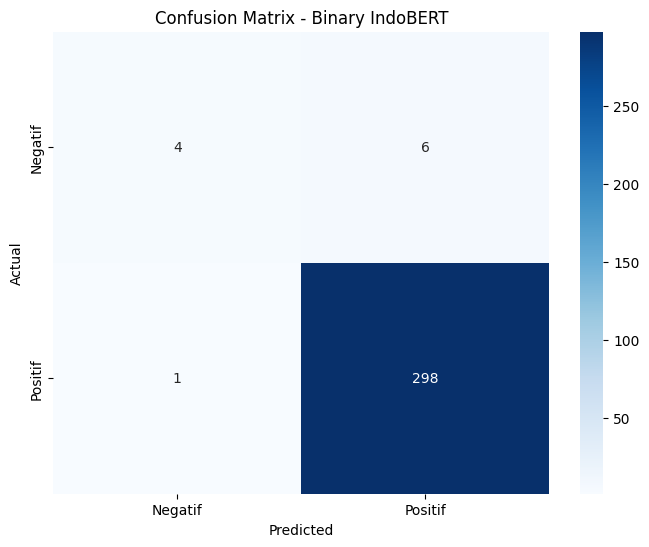

In [8]:
# Evaluation
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)
        
        outputs = model(ids, attention_mask=mask)
        preds = torch.max(outputs.logits, dim=1)[1]
        
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(targets.cpu().numpy())

print("\n--- BINARY CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=list(LABEL_MAP.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(LABEL_MAP.keys()), yticklabels=list(LABEL_MAP.keys()))
plt.title("Confusion Matrix - Binary IndoBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(FIG_DIR, "binary_confusion_matrix.png"))
plt.show()

In [9]:
# Save Model
print(f"Saving model to {OUTPUT_DIR}...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Done!")

Saving model to /content/drive/MyDrive/xai_lime_vs_shap/outputs/indobert_binary...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done!
